In [1]:
import requests
import json
import csv
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
url = "https://services.nvd.nist.gov/rest/json/cves/2.0"

response = requests.get(url, params={"resultsPerPage": 5})

print("Status Code:", response.status_code)

if response.status_code == 200:
    print("NVD API connected successfully!")
else:
    print("API connection failed.")

Status Code: 200
NVD API connected successfully!


In [3]:
technologies = [
    "WordPress",
    "PHP",
    "MySQL"
]

print("Selected Technology Stack:")
for tech in technologies:
    print("-", tech)

Selected Technology Stack:
- WordPress
- PHP
- MySQL


In [4]:
import requests
from datetime import datetime, timedelta, timezone

# NVD API
url = "https://services.nvd.nist.gov/rest/json/cves/2.0"

# Last 90 days
end_date = datetime.now(timezone.utc)
start_date = end_date - timedelta(days=90)

params = {
    "keywordSearch": "WordPress",
    "pubStartDate": start_date.strftime("%Y-%m-%dT%H:%M:%S.000Z"),
    "pubEndDate": end_date.strftime("%Y-%m-%dT%H:%M:%S.000Z"),
    "resultsPerPage": 20
}

response = requests.get(url, params=params)

print("Status Code:", response.status_code)

if response.status_code == 200:
    data = response.json()
    print("Total CVEs found:", data.get("totalResults", 0))
else:
    print("Error:", response.text)

Status Code: 200
Total CVEs found: 1988


In [5]:
import requests
from datetime import datetime, timedelta, timezone

# NVD API URL
url = "https://services.nvd.nist.gov/rest/json/cves/2.0"

# Last 90 days ka data
end_date = datetime.now(timezone.utc)
start_date = end_date - timedelta(days=90)

# WordPress CVEs search
params = {
    "keywordSearch": "WordPress",
    "pubStartDate": start_date.strftime("%Y-%m-%dT%H:%M:%S.000Z"),
    "pubEndDate": end_date.strftime("%Y-%m-%dT%H:%M:%S.000Z"),
    "resultsPerPage": 20
}

response = requests.get(url, params=params)

print("Status Code:", response.status_code)

if response.status_code == 200:
    data = response.json()
    print("Total CVEs found:", data.get("totalResults", 0))
else:
    print("Error:", response.text)

Status Code: 200
Total CVEs found: 1991


In [6]:
# CVE details extract karna

cve_list = data.get("vulnerabilities", [])

print("CVE records retrieved:", len(cve_list))
print("\nFirst 5 CVEs:\n")

for item in cve_list[:5]:
    cve = item["cve"]

    cve_id = cve.get("id", "N/A")
    description = cve.get("descriptions", [{}])[0].get("value", "N/A")

    print("CVE ID:", cve_id)
    print("Description:", description[:300])
    print("-" * 80)

CVE records retrieved: 20

First 5 CVEs:

CVE ID: CVE-2021-47982
Description: WordPress Plugin WP-Paginate 2.1.3 contains a stored cross-site scripting vulnerability that allows authenticated attackers to inject malicious scripts by manipulating the preset parameter. Attackers can submit POST requests to the plugin settings page with script payloads in the preset parameter th
--------------------------------------------------------------------------------
CVE ID: CVE-2021-47983
Description: WordPress Plugin Stripe Payments before 2.0.40 contains a stored cross-site scripting vulnerability that allows authenticated attackers to inject malicious scripts through the AcceptStripePayments-settings[currency_code] parameter. Attackers can submit POST requests to /wp-admin/options.php with scr
--------------------------------------------------------------------------------
CVE ID: CVE-2021-47984
Description: WordPress Plugin WP24 Domain Check 1.6.2 contains a stored cross-site scripting vulner

In [7]:
def get_severity(score):
    if score is None:
        return "Unknown"
    elif score >= 9.0:
        return "Critical"
    elif score >= 7.0:
        return "High"
    elif score >= 4.0:
        return "Medium"
    else:
        return "Low"


for item in cve_list[:5]:
    cve = item["cve"]

    cve_id = cve.get("id", "N/A")

    # CVSS score
    metrics = cve.get("metrics", {})
    score = None

    if "cvssMetricV40" in metrics:
        score = metrics["cvssMetricV40"][0]["cvssData"].get("baseScore")
    elif "cvssMetricV31" in metrics:
        score = metrics["cvssMetricV31"][0]["cvssData"].get("baseScore")
    elif "cvssMetricV30" in metrics:
        score = metrics["cvssMetricV30"][0]["cvssData"].get("baseScore")

    severity = get_severity(score)

    print("CVE ID:", cve_id)
    print("CVSS Score:", score)
    print("Severity:", severity)
    print("-" * 50)

CVE ID: CVE-2021-47982
CVSS Score: 5.1
Severity: Medium
--------------------------------------------------
CVE ID: CVE-2021-47983
CVSS Score: 5.1
Severity: Medium
--------------------------------------------------
CVE ID: CVE-2021-47984
CVSS Score: 5.1
Severity: Medium
--------------------------------------------------
CVE ID: CVE-2022-50953
CVSS Score: 6.9
Severity: Medium
--------------------------------------------------
CVE ID: CVE-2023-54350
CVSS Score: 8.7
Severity: High
--------------------------------------------------


In [8]:
# CVE information ko table mein display karna

rows = []

for item in cve_list:
    cve = item["cve"]

    cve_id = cve.get("id", "N/A")

    # Description
    descriptions = cve.get("descriptions", [])
    description = descriptions[0].get("value", "N/A") if descriptions else "N/A"

    # Published date
    published = cve.get("published", "N/A")

    # CVSS
    metrics = cve.get("metrics", {})
    score = None

    if "cvssMetricV40" in metrics:
        score = metrics["cvssMetricV40"][0]["cvssData"].get("baseScore")
    elif "cvssMetricV31" in metrics:
        score = metrics["cvssMetricV31"][0]["cvssData"].get("baseScore")
    elif "cvssMetricV30" in metrics:
        score = metrics["cvssMetricV30"][0]["cvssData"].get("baseScore")

    severity = get_severity(score)

    rows.append({
        "CVE ID": cve_id,
        "Published": published[:10],
        "CVSS Score": score,
        "Severity": severity,
        "Summary": description[:150]
    })

df = pd.DataFrame(rows)

# Highest severity/score first
severity_order = {
    "Critical": 4,
    "High": 3,
    "Medium": 2,
    "Low": 1,
    "Unknown": 0
}

df["Severity Rank"] = df["Severity"].map(severity_order)

df = df.sort_values(
    by=["Severity Rank", "CVSS Score"],
    ascending=[False, False]
).drop(columns=["Severity Rank"])

display(df)

,CVE ID,Published,CVSS Score,Severity,Summary
6,CVE-2023-54352,2026-06-08,9.3,Critical,WordPress Seotheme contains a remote code exec...
7,CVE-2024-58348,2026-06-08,9.3,Critical,WordPress Background Image Cropper version 1.2...
8,CVE-2024-58349,2026-06-08,9.3,Critical,WordPress Theme Travelscape 1.0.3 contains an ...
4,CVE-2023-54350,2026-06-08,8.7,High,WordPress Augmented-Reality plugin contains a ...
12,CVE-2026-7556,2026-06-09,7.2,High,The FV Flowplayer Video Player plugin for Word...
3,CVE-2022-50953,2026-06-08,6.9,Medium,WordPress Plugin admin-word-count-column 2.2 c...
9,CVE-2026-3011,2026-06-08,6.4,Medium,The Recipe Card Blocks Lite plugin for WordPre...
10,CVE-2026-10862,2026-06-09,6.4,Medium,The Accordions plugin for WordPress is vulnera...
11,CVE-2026-5714,2026-06-09,6.4,Medium,The Enable Media Replace plugin for WordPress ...
13,CVE-2026-10024,2026-06-09,6.4,Medium,The TinyMCE shortcode Addon plugin for WordPre...


In [9]:
# Affected versions aur patch priority add karna

def get_patch_priority(severity):
    if severity == "Critical":
        return "PATCH IMMEDIATELY"
    elif severity == "High":
        return "PATCH AS SOON AS POSSIBLE"
    elif severity == "Medium":
        return "PATCH IN NORMAL MAINTENANCE WINDOW"
    elif severity == "Low":
        return "MONITOR / PATCH WHEN PRACTICAL"
    else:
        return "REVIEW MANUALLY"


df["Patch Priority"] = df["Severity"].apply(get_patch_priority)

# Recommended action
def get_recommendation(severity):
    if severity == "Critical":
        return "Apply the vendor's fixed version immediately and verify the system."
    elif severity == "High":
        return "Upgrade to the latest secure/fixed version as soon as possible."
    elif severity == "Medium":
        return "Apply the available security update during the normal maintenance window."
    elif severity == "Low":
        return "Monitor the vulnerability and apply the available update when practical."
    else:
        return "Review the original NVD/vendor advisory manually."

df["Recommended Action"] = df["Severity"].apply(get_recommendation)

display(df)

,CVE ID,Published,CVSS Score,Severity,Summary,Patch Priority,Recommended Action
6,CVE-2023-54352,2026-06-08,9.3,Critical,WordPress Seotheme contains a remote code exec...,PATCH IMMEDIATELY,Apply the vendor's fixed version immediately a...
7,CVE-2024-58348,2026-06-08,9.3,Critical,WordPress Background Image Cropper version 1.2...,PATCH IMMEDIATELY,Apply the vendor's fixed version immediately a...
8,CVE-2024-58349,2026-06-08,9.3,Critical,WordPress Theme Travelscape 1.0.3 contains an ...,PATCH IMMEDIATELY,Apply the vendor's fixed version immediately a...
4,CVE-2023-54350,2026-06-08,8.7,High,WordPress Augmented-Reality plugin contains a ...,PATCH AS SOON AS POSSIBLE,Upgrade to the latest secure/fixed version as ...
12,CVE-2026-7556,2026-06-09,7.2,High,The FV Flowplayer Video Player plugin for Word...,PATCH AS SOON AS POSSIBLE,Upgrade to the latest secure/fixed version as ...
3,CVE-2022-50953,2026-06-08,6.9,Medium,WordPress Plugin admin-word-count-column 2.2 c...,PATCH IN NORMAL MAINTENANCE WINDOW,Apply the available security update during the...
9,CVE-2026-3011,2026-06-08,6.4,Medium,The Recipe Card Blocks Lite plugin for WordPre...,PATCH IN NORMAL MAINTENANCE WINDOW,Apply the available security update during the...
10,CVE-2026-10862,2026-06-09,6.4,Medium,The Accordions plugin for WordPress is vulnera...,PATCH IN NORMAL MAINTENANCE WINDOW,Apply the available security update during the...
11,CVE-2026-5714,2026-06-09,6.4,Medium,The Enable Media Replace plugin for WordPress ...,PATCH IN NORMAL MAINTENANCE WINDOW,Apply the available security update during the...
13,CVE-2026-10024,2026-06-09,6.4,Medium,The TinyMCE shortcode Addon plugin for WordPre...,PATCH IN NORMAL MAINTENANCE WINDOW,Apply the available security update during the...


In [10]:
# Final vulnerability reports generate karna

import os
import json

# Output folder
os.makedirs("output", exist_ok=True)

# JSON report
json_report = {
    "project": "CVE Research & Vulnerability Report Generator",
    "technology_stack": technologies,
    "total_cves_analyzed": len(df),
    "vulnerabilities": df.to_dict(orient="records")
}

with open("output/vulnerability_report.json", "w", encoding="utf-8") as f:
    json.dump(json_report, f, indent=4, ensure_ascii=False)

# CSV report
df.to_csv(
    "output/vulnerability_report.csv",
    index=False,
    encoding="utf-8"
)

print("Reports generated successfully!")
print("JSON: output/vulnerability_report.json")
print("CSV:  output/vulnerability_report.csv")

Reports generated successfully!
JSON: output/vulnerability_report.json
CSV:  output/vulnerability_report.csv


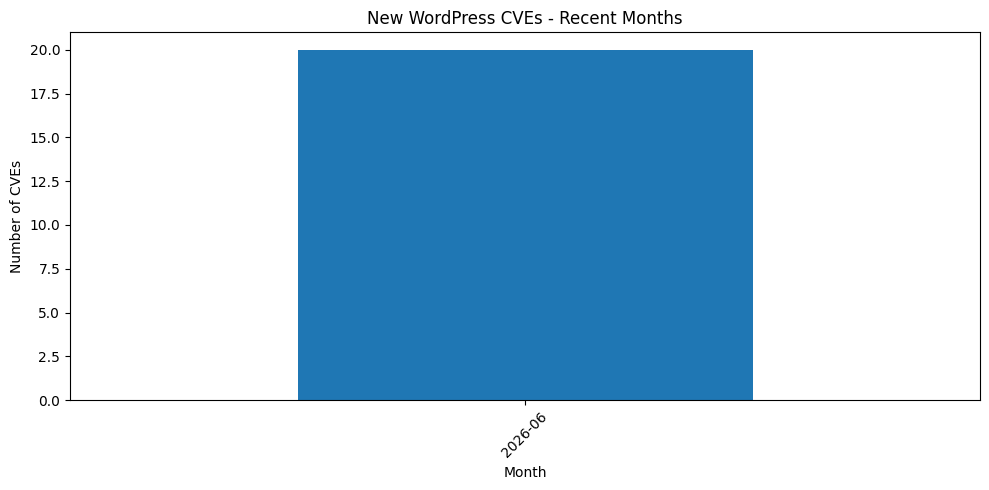

Trend chart saved successfully!


In [11]:
# CVE Trend Chart - Last 3 Months

df["Published"] = pd.to_datetime(df["Published"])

# Month-wise CVE count
monthly_cves = df.groupby(
    df["Published"].dt.to_period("M")
).size()

plt.figure(figsize=(10, 5))

monthly_cves.plot(kind="bar")

plt.title("New WordPress CVEs - Recent Months")
plt.xlabel("Month")
plt.ylabel("Number of CVEs")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("output/cve_trend.png")
plt.show()

print("Trend chart saved successfully!")